<a href="https://colab.research.google.com/github/harabou/NCD_biostat/blob/main/%2307_ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 10.9 MB/s eta 0:00:00


In [15]:
!pip install japanize-matplotlib
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 54.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=3aa1506988287e61a2d82468b911a996ee75b5b3ce34d0512a2ff362f284fe2b
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


1. 一元配置分散分析 (One-way ANOVA)
資料の「病院間での手術時間の比較」

In [5]:
import pandas as pd
import pingouin as pg

# データの読み込み（アップロードしたCSVファイル名に合わせてください）
fpath ='https://raw.githubusercontent.com/harabou/NCD_biostat/refs/heads/main/%2307/hospitalx.csv' #hospitalx.csv
df_hosital= pd.read_csv(fpath,header=0,sep=',',encoding='utf-8')
df_hosital

# 分散分析の実行
# jikan: 目的変数(Y), shisetsu: 説明変数(X)
aov = pg.anova(dv='jikan', between='shisetsu', data=df_hosital, detailed=True)
print("--- ANOVA Table ---")
print(aov)

# 多重比較 (Tukey's test)
posthoc = pg.pairwise_tukey(dv='jikan', between='shisetsu', data=df_hosital)
print("\n--- Post-hoc (Tukey) ---")
print(posthoc)

--- ANOVA Table ---
     Source            SS  DF            MS         F    p_unc       np2
0  shisetsu  57773.333333   2  28886.666667  4.885006  0.02805  0.448783
1    Within  70960.000000  12   5913.333333       NaN      NaN       NaN

--- Post-hoc (Tukey) ---
   A  B  mean_A  mean_B   diff         se         T   p_tukey    hedges
0  A  B   520.0   442.0   78.0  48.634693  1.603793  0.281592  0.942713
1  A  C   520.0   368.0  152.0  48.634693  3.125341  0.022145  1.639762
2  B  C   442.0   368.0   74.0  48.634693  1.521548  0.315863  0.931827


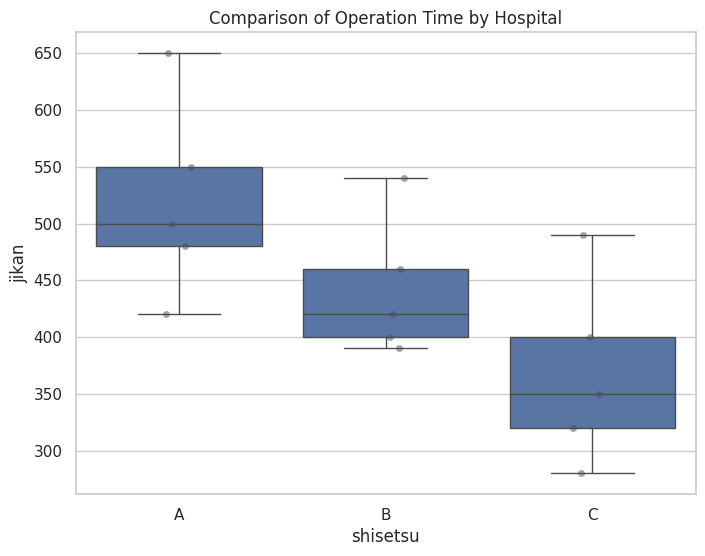

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# グラフのスタイル設定
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x='shisetsu', y='jikan', data=df_hosital)
sns.stripplot(x='shisetsu', y='jikan', data=df_hosital, color=".3", alpha=0.5) # 個別のデータ点も重ねる
plt.title('Comparison of Operation Time by Hospital')
plt.show()

２．反復測定分散分析 (Repeated Measures ANOVA)
「時間経過による血圧の変化」

In [12]:
fpath ='https://raw.githubusercontent.com/harabou/NCD_biostat/refs/heads/main/%2307/bp_long.csv'
df_bp =  pd.read_csv(fpath,header=0,sep=',',encoding='utf-8')
df_bp

# 反復測定分散分析 (時間要因)
# dv: 目的変数(sbp), within: 内要因(time), subject: 個体ID(id)
res_rm = pg.rm_anova(dv='sbp', within='time', subject='id', data=df_bp)
print("--- Repeated Measures ANOVA ---")
print(res_rm)

# 球形定検定 (Sphericity test) [cite: 28, 29]
sphericity = pg.sphericity(data=df_bp, dv='sbp', within='time', subject='id')
print("\n--- Mauchly's Sphericity Test ---")
print(sphericity)

--- Repeated Measures ANOVA ---
  Source  ddof1  ddof2        F     p_unc       ng2       eps
0   time      2     22  9.80363  0.000903  0.268248  0.816891

--- Mauchly's Sphericity Test ---
SpherResults(spher=True, W=np.float64(0.7758466180576177), chi2=np.float64(2.538004354779109), dof=2, pval=np.float64(0.28111198177182684))


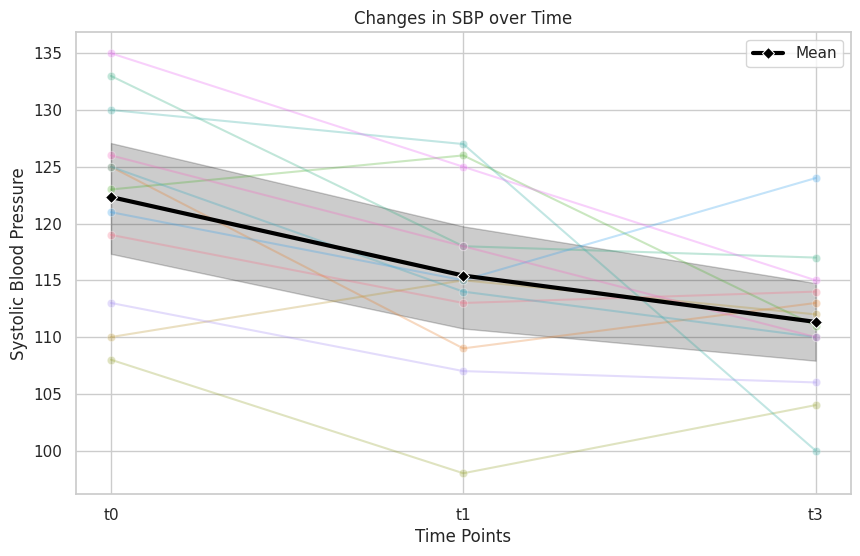

In [14]:
plt.figure(figsize=(10, 6))
# 個体ごとの推移
sns.lineplot(x='time', y='sbp', hue='id', data=df_bp, marker='o', legend=False, alpha=0.3)
# 全体の平均推移（太線）
sns.lineplot(x='time', y='sbp', data=df_bp, color='black', linewidth=3, marker='D', label='Mean')

plt.title('Changes in SBP over Time')
plt.xlabel('Time Points')
plt.ylabel('Systolic Blood Pressure')
plt.show()

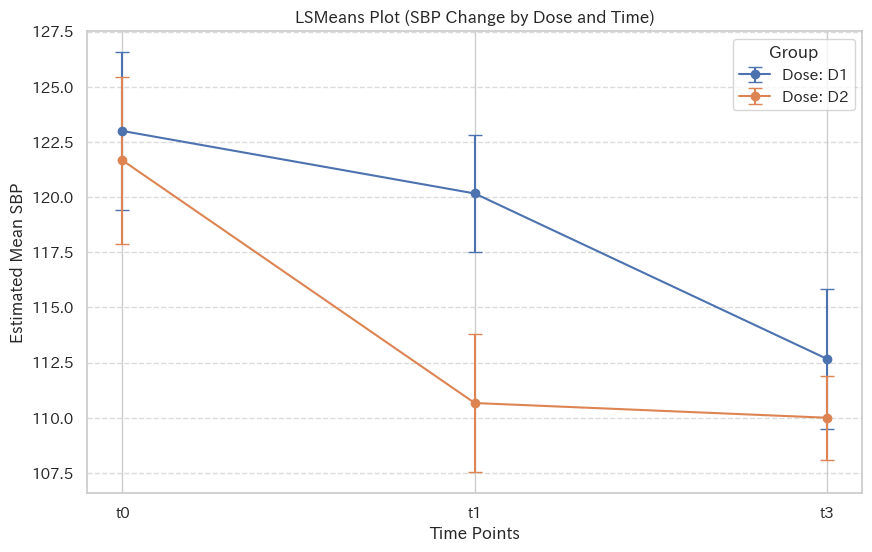

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np

# 1. データの読み込み
fpath ='https://raw.githubusercontent.com/harabou/NCD_biostat/refs/heads/main/%2307/bp_long.csv'
df_bp =  pd.read_csv(fpath,header=0,sep=',',encoding='utf-8')
df_bp

# 2. 混合モデルの適合 (doseとtimeの相互作用を考慮)
model = smf.mixedlm("sbp ~ dose * time", df_bp, groups=df_bp["id"]).fit()

# 3. 平均値と標準誤差の計算
# プロット用に各群（dose × time）の平均とSEを算出します
lsmeans = df_bp.groupby(['time', 'dose'])['sbp'].agg(['mean', 'sem']).reset_index()

# 4. プロットの作成
plt.figure(figsize=(10, 6))

# doseごとに線とエラーバーを描画
for dose in lsmeans['dose'].unique():
    subset = lsmeans[lsmeans['dose'] == dose]
    plt.errorbar(x=subset['time'], y=subset['mean'], yerr=subset['sem'],
                 label=f'Dose: {dose}', capsize=5, marker='o', linestyle='-')

plt.title('LSMeans Plot (SBP Change by Dose and Time)')
plt.xlabel('Time Points')
plt.ylabel('Estimated Mean SBP')
plt.legend(title='Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
import statsmodels.formula.api as smf

# 混合モデルの実行
# 固定効果: dose, time, dose:time(相互作用)
# 変量効果: id (個体差)
md = smf.mixedlm("sbp ~ dose * time", df_bp, groups=df_bp["id"])
mdf = md.fit()
print(mdf.summary())

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     sbp      
No. Observations:     36          Method:                 REML     
No. Groups:           12          Scale:                  35.8720  
Min. group size:      3           Log-Likelihood:         -106.8156
Max. group size:      3           Converged:              Yes      
Mean group size:      3.0                                          
-------------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------
Intercept             123.000    3.097 39.711 0.000 116.929 129.071
dose[T.D2]             -1.333    4.380 -0.304 0.761  -9.919   7.252
time[T.t1]             -2.833    3.458 -0.819 0.413  -9.611   3.944
time[T.t3]            -10.333    3.458 -2.988 0.003 -17.111  -3.556
dose[T.D2]:time[T.t1]  -8.167    4.890 -1.670 0.095 -17.751   1

3. 二元配置分散分析 (Two-way ANOVA)
「薬剤・性別・相互作用の解析」

In [9]:
fpath ='https://raw.githubusercontent.com/harabou/NCD_biostat/refs/heads/main/%2307/2way.csv' #2way.csv
df_2way= pd.read_csv(fpath,header=0,sep=',',encoding='utf-8')
df_2way


# 二元配置分散分析の実行（相互作用も含む）
# score: 目的変数, drug/sex: 説明変数
aov_2way = pg.anova(dv='score', between=['drug', 'sex'], data=df_2way)
print("--- Two-way ANOVA Table ---")
print(aov_2way)

--- Two-way ANOVA Table ---
       Source          SS    DF         MS          F     p_unc       np2
0        drug   52.469227   2.0  26.234614   5.281671  0.009895  0.231839
1         sex   87.862457   1.0  87.862457  17.688867  0.000171  0.335723
2  drug * sex   33.602391   2.0  16.801196   3.382493  0.045392  0.161977
3    Residual  173.848669  35.0   4.967105        NaN       NaN       NaN


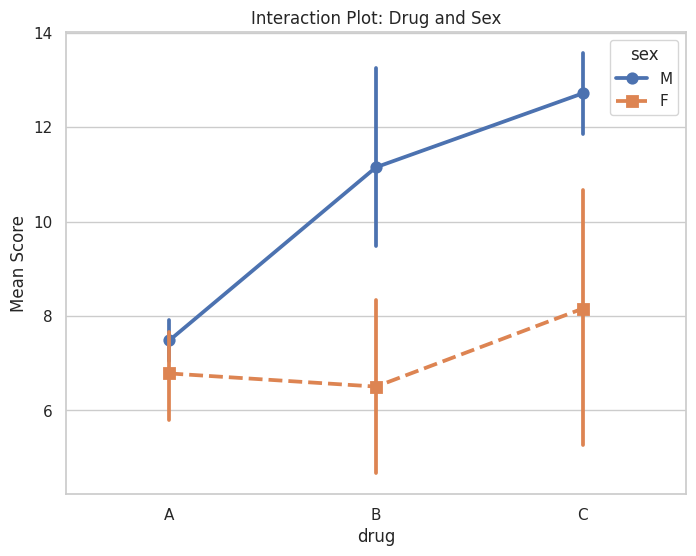

In [10]:
plt.figure(figsize=(8, 6))
sns.pointplot(x='drug', y='score', hue='sex', data=df_2way, markers=["o", "s"], linestyles=["-", "--"])
plt.title('Interaction Plot: Drug and Sex')
plt.ylabel('Mean Score')
plt.show()